# Notebook 2 - Feature Engineering

Importando bibliotecas:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Lendo o dataset .parquet:

In [2]:
df = pd.read_parquet('../data/processed/dados_eda.parquet')
df.head()

,inadimplente,uso_credito_rotativo,idade,atrasos_30_59_dias,razao_divida_renda,renda_mensal,linhas_credito_abertas,atrasos_90_dias_ou_mais,emprestimos_imobiliarios,atrasos_60_89_dias,num_dependentes
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Tratando outliers:

No notebook 1 foi possível observar que as seguintes variáveis precisam ser tratadas:

* uso_credito_rotativo: valor maior que 1 (impossível, pois é uma razão)
* razao_divida_renda: valores impossíveis, na prática
* idade: idade = 0 é impossível, tratar com base na moda
* 98 nos atrasados: muito improvável que alguém tenha 98 atrasos no banco

### Tratando uso_credito_rotativo:

In [3]:
acima_de_1 = df[df['uso_credito_rotativo'] > 1]
print(f"Valores > 1: {len(acima_de_1)} ({len(acima_de_1)/len(df)*100:.2f}%)")

Valores > 1: 3321 (2.22%)


In [4]:
print(acima_de_1['uso_credito_rotativo'].describe())

count     3321.000000
mean       259.773362
std       1659.034074
min          1.000059
25%          1.019996
50%          1.074633
75%          1.301096
max      50708.000000
Name: uso_credito_rotativo, dtype: float64


In [5]:
acima_de_100 = df[df['uso_credito_rotativo'] > 100]
print(f"Valores > 100: {len(acima_de_100)} ({len(acima_de_100)/len(df)*100:.2f}%)")

Valores > 100: 223 (0.15%)


Criando função para corrigir os valores com base nas seguintes regras:

* Valores até 1.5 podem ser apenas um estouro de até 50% no limite
* Valores menores ou iguais a 100 podem ser um erro de digitação (digitar 50 ao invés de 0.5)
* Capping para valores absurdos (como 50708). Considerando que valores acima de 100 são apenas 0.15% do dataset, capping parece uma estratégia segura.

In [6]:
def corrigir_uso_credito(valor):
    if valor <= 1.5:
        return valor
    elif valor <= 100:
        return valor/100
    else:
        return 1.0

In [7]:
df['uso_credito_rotativo'] = df['uso_credito_rotativo'].apply(corrigir_uso_credito)

In [8]:
print(df['uso_credito_rotativo'].describe())
print(f"Valores > 1.5: {(df['uso_credito_rotativo'] > 1.5).sum()}")

count    149391.000000
mean          0.317812
std           0.351178
min           0.000000
25%           0.029647
50%           0.151996
75%           0.550172
max           1.499474
Name: uso_credito_rotativo, dtype: float64
Valores > 1.5: 0


### Tratando idade:

In [9]:
invalidos = df[df['idade'] < 18]
print(f"Idades < 18: {len(invalidos)} ({len(invalidos)/len(df)*100:.3f}%)")
print(invalidos['idade'].value_counts())

Idades < 18: 1 (0.001%)
idade
0    1
Name: count, dtype: int64


In [10]:
df = df[df['idade'] >= 18]

In [11]:
invalidos = df[df['idade'] < 18]
print(f"Idades < 18: {len(invalidos)} ({len(invalidos)/len(df)*100:.3f}%)")
print(invalidos['idade'].value_counts())

Idades < 18: 0 (0.000%)
Series([], Name: count, dtype: int64)


### Tratando razao_divida_renda

In [12]:
print(df['razao_divida_renda'].describe())

count    149390.000000
mean        354.439110
std        2041.850084
min           0.000000
25%           0.177441
50%           0.368233
75%           0.875294
max      329664.000000
Name: razao_divida_renda, dtype: float64


In [13]:
print(f"\nPercentis altos:")
print(df['razao_divida_renda'].quantile([0.90, 0.95, 0.99, 0.999]))


Percentis altos:
0.900     1275.000
0.950     2455.550
0.990     4985.110
0.999    10658.214
Name: razao_divida_renda, dtype: float64


In [14]:
print(df['razao_divida_renda'].quantile([0.50, 0.75, 0.90, 0.95, 0.975, 0.99]))

0.500       0.368233
0.750       0.875294
0.900    1275.000000
0.950    2455.550000
0.975    3494.000000
0.990    4985.110000
Name: razao_divida_renda, dtype: float64


In [15]:
print(f"Valores <= 1: {(df['razao_divida_renda'] <= 1).sum()}")
print(f"Valores entre 1 e 10: {((df['razao_divida_renda'] > 1) & (df['razao_divida_renda'] <= 10)).sum()}")
print(f"Valores > 10: {(df['razao_divida_renda'] > 10).sum()}")

Valores <= 1: 114260
Valores entre 1 e 10: 6257
Valores > 10: 28873


In [16]:
extremos = df[df['razao_divida_renda'] > 10]
print(extremos['renda_mensal'].describe())

count    28873.000000
mean      5014.763239
std       1397.812799
min          0.000000
25%       5400.000000
50%       5400.000000
75%       5400.000000
max      16500.000000
Name: renda_mensal, dtype: float64


Com isto, pode-se observar que os percentis 25, 50 e 75% todos são 5400, que é o valor da mediana usando para imputar renda_mensal no notebook 1. Com isso, os valores extremos são erros nos dados originais e deve-se usar capping em 1 como estratégia:

In [17]:
df['razao_extrema'] = (df['razao_divida_renda'] > 1).astype(int)

In [18]:
df['razao_divida_renda'] = df['razao_divida_renda'].clip(upper=1)

In [19]:
print(df['razao_divida_renda'].describe())

count    149390.000000
mean          0.468119
std           0.354926
min           0.000000
25%           0.177441
50%           0.368233
75%           0.875294
max           1.000000
Name: razao_divida_renda, dtype: float64


In [20]:
print(f"\nDistribuição razao_extrema:\n{df['razao_extrema'].value_counts()}")


Distribuição razao_extrema:
razao_extrema
0    114260
1     35130
Name: count, dtype: int64


Para não perder a informação de que 19% tinha divídas altíssimas, deve-se criar uma variável binária para preservar a informação de quem tinha valor extremo numa feature separada.

### Tratando as variáveis de atraso

No kaggle, '98' significa OU muitas atrasos ou informação desconhecida. Vou considerar que significa muitos atrasos

In [21]:
for col in ['atrasos_30_59_dias', 'atrasos_60_89_dias', 'atrasos_90_dias_ou_mais']:
    qtd_98 = (df[col] == 98).sum()
    print(f"{col}: {qtd_98} valores = 98")

atrasos_30_59_dias: 220 valores = 98
atrasos_60_89_dias: 220 valores = 98
atrasos_90_dias_ou_mais: 220 valores = 98


In [22]:
for col in ['atrasos_30_59_dias', 'atrasos_60_89_dias', 'atrasos_90_dias_ou_mais']:
    valores_reais = df[df[col] < 98][col]
    print(f"{col}: max real = {valores_reais.max()}")

atrasos_30_59_dias: max real = 96
atrasos_60_89_dias: max real = 96
atrasos_90_dias_ou_mais: max real = 96


In [23]:
for col in ['atrasos_30_59_dias', 'atrasos_60_89_dias', 'atrasos_90_dias_ou_mais']:
    print(f"\n{col}:")
    print(df[col].quantile([0.90, 0.95, 0.99]))


atrasos_30_59_dias:
0.90    1.0
0.95    2.0
0.99    4.0
Name: atrasos_30_59_dias, dtype: float64

atrasos_60_89_dias:
0.90    0.0
0.95    1.0
0.99    2.0
Name: atrasos_60_89_dias, dtype: float64

atrasos_90_dias_ou_mais:
0.90    0.0
0.95    1.0
0.99    3.0
Name: atrasos_90_dias_ou_mais, dtype: float64


Tratando com capping:

In [24]:
for col in ['atrasos_30_59_dias', 'atrasos_60_89_dias', 'atrasos_90_dias_ou_mais']:
    df[col] = df[col].clip(upper=10)

In [25]:
print(df[['atrasos_30_59_dias', 'atrasos_60_89_dias', 'atrasos_90_dias_ou_mais']].describe())

       atrasos_30_59_dias  atrasos_60_89_dias  atrasos_90_dias_ou_mais
count       149390.000000       149390.000000            149390.000000
mean             0.261356            0.080025                 0.105342
std              0.793517            0.507422                 0.613641
min              0.000000            0.000000                 0.000000
25%              0.000000            0.000000                 0.000000
50%              0.000000            0.000000                 0.000000
75%              0.000000            0.000000                 0.000000
max             10.000000           10.000000                10.000000


## Engenharia de Atributos

Criando novos atributos que podem ser interessantes:

In [26]:
df['total_atrasos'] = df['atrasos_30_59_dias'] + df['atrasos_60_89_dias'] + df['atrasos_90_dias_ou_mais']

df['tem_atraso_grave'] = (df['atrasos_90_dias_ou_mais'] > 0).astype(int)

df['renda_per_capita'] = df['renda_mensal']/(1 + df['num_dependentes'])

df["faixa_etaria"] = pd.cut(df['idade'], bins=[18, 30, 45, 60, 120], labels=['jovem', 'adulto', 'meia_idade', 'senior'])

Medindo a correlação (spearman) dos novos atributos com o target:

In [27]:
novas_features = ['total_atrasos', 'tem_atraso_grave', 'renda_per_capita']
print(df[novas_features + ['inadimplente']].corr(method='spearman')['inadimplente'])

total_atrasos       0.340512
tem_atraso_grave    0.339867
renda_per_capita   -0.075784
inadimplente        1.000000
Name: inadimplente, dtype: float64


In [28]:
df.groupby('faixa_etaria')['inadimplente'].mean().sort_values(ascending=False)

/tmp/ipykernel_11242/1920436913.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('faixa_etaria')['inadimplente'].mean().sort_values(ascending=False)


faixa_etaria
jovem         0.117078
adulto        0.093173
meia_idade    0.068232
senior        0.030115
Name: inadimplente, dtype: float64

Com estes resultados, pode-se concluir duas coisas:

1. Ter atraso importa mais do que quantos atrasos a pessoa tem
2. A feature de faixa_etaria é útil. Quanto mais jovem, maior a correlação (dentro do esperado)

## Encoding

Aplicar One-Hot Encoding para a coluna 'faixa-etaria':

In [29]:
df = pd.get_dummies(df, columns=['faixa_etaria'], prefix='faixa', dtype=int)

In [30]:
df.head()

,inadimplente,uso_credito_rotativo,idade,atrasos_30_59_dias,razao_divida_renda,renda_mensal,linhas_credito_abertas,atrasos_90_dias_ou_mais,emprestimos_imobiliarios,atrasos_60_89_dias,num_dependentes,razao_extrema,total_atrasos,tem_atraso_grave,renda_per_capita,faixa_jovem,faixa_adulto,faixa_meia_idade,faixa_senior
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,2,0,3040.0,0,1,0,0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0,0,1300.0,0,1,0,0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,2,1,3042.0,0,1,0,0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0,0,3300.0,1,0,0,0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0,1,0,63588.0,0,0,1,0


## Transformação Logarítmica

In [31]:
df['log_renda_mensal'] = np.log1p(df['renda_mensal'])
df['log_renda_per_capita'] = np.log1p(df['renda_per_capita'])

print("Antes vs Depois da transformação:")
print(f"\nrenda_mensal - Skewness: {df['renda_mensal'].skew():.2f}")
print(f"log_renda_mensal - Skewness: {df['log_renda_mensal'].skew():.2f}")

print(f"\nrenda_per_capita - Skewness: {df['renda_per_capita'].skew():.2f}")
print(f"log_renda_per_capita - Skewness: {df['log_renda_per_capita'].skew():.2f}")

Antes vs Depois da transformação:

renda_mensal - Skewness: 126.89
log_renda_mensal - Skewness: -4.94

renda_per_capita - Skewness: 105.56
log_renda_per_capita - Skewness: -4.06


## Removendo variáveis redundantes

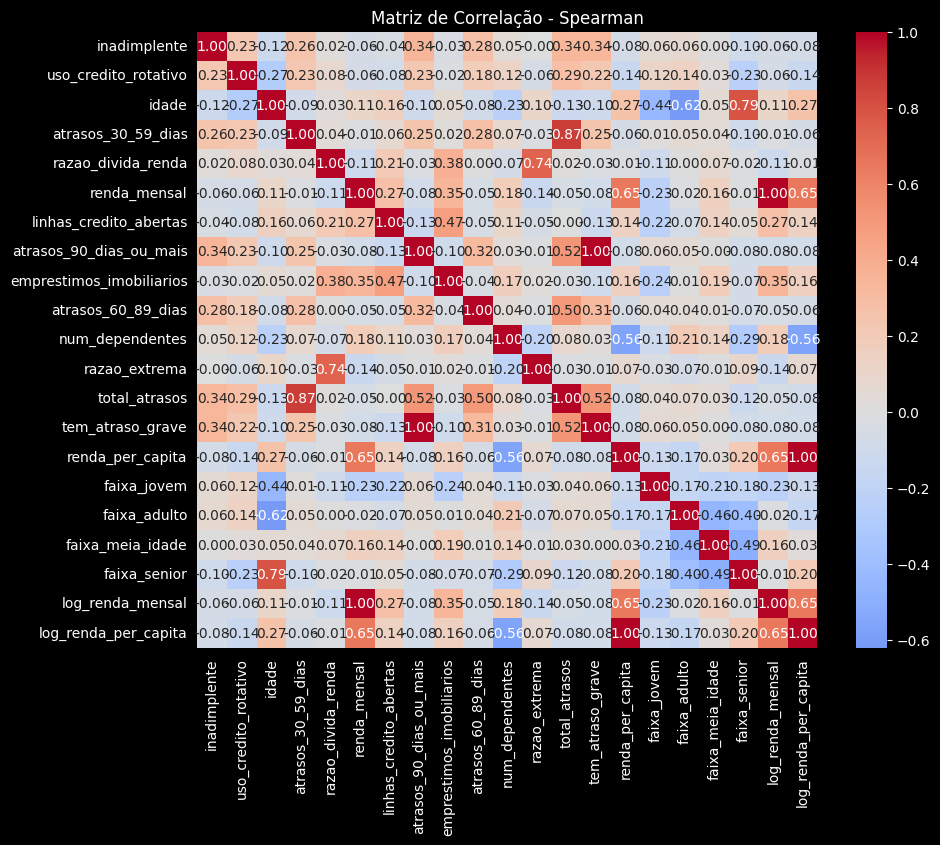

In [32]:
corr = df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlação - Spearman')
plt.show()

In [33]:
colunas=['inadimplente', 'log_renda_mensal', 'tem_atraso_grave', 'total_atrasos', 'idade', 'uso_credito_rotativo', 'razao_divida_renda', 'razao_extrema', 'num_dependentes', 'linhas_credito_abertas', 'emprestimos_imobiliarios'] # variáveis que vão ser mantidas

df = df[colunas]

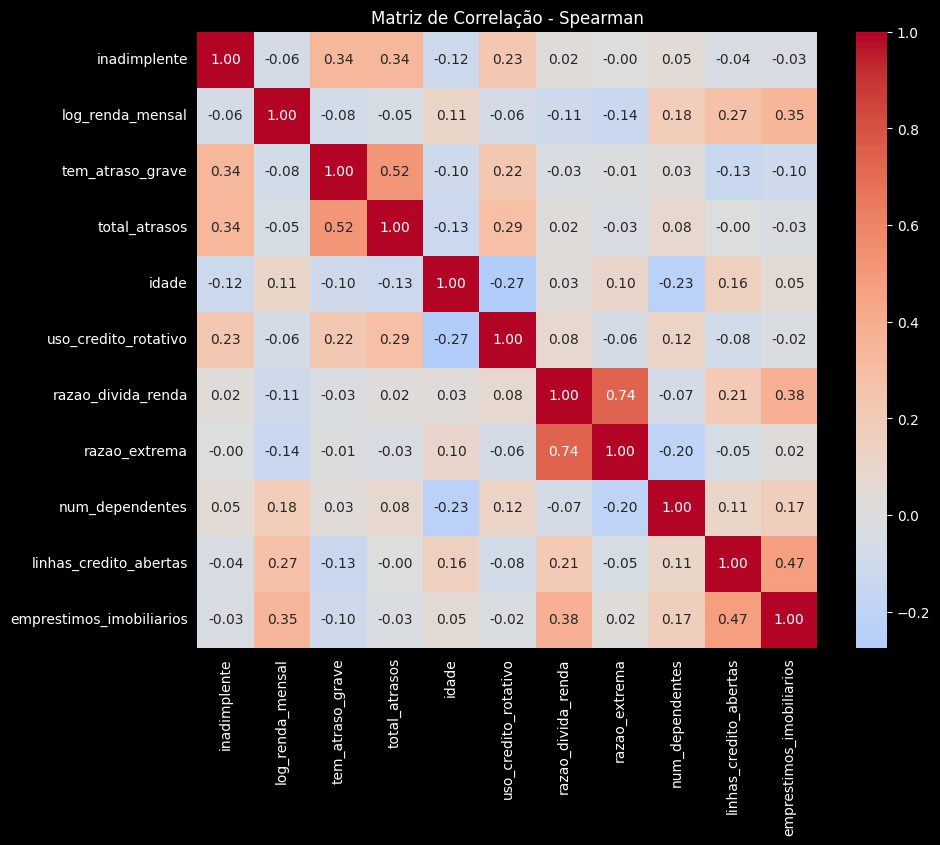

In [34]:
corr = df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlação - Spearman')
plt.show()

## Exportando os dados

In [35]:
df.to_parquet('../data/features/dados_modelo.parquet')

In [36]:
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nTipos de dados:\n{df.dtypes}")

Missing values: 0

Tipos de dados:
inadimplente                  int64
log_renda_mensal            float64
tem_atraso_grave              int64
total_atrasos                 int64
idade                         int64
uso_credito_rotativo        float64
razao_divida_renda          float64
razao_extrema                 int64
num_dependentes             float64
linhas_credito_abertas        int64
emprestimos_imobiliarios      int64
dtype: object


## Resumo das Transformações

  ### Outliers tratados:
  - `uso_credito_rotativo`: valores >1 corrigidos/capping em 1
  - `idade`: removida 1 linha com valor < 18
  - `razao_divida_renda`: capping em 1
  - `atrasos_*`: capping em 10

  ### Features criadas:
  - `razao_extrema`: flag para razão dívida/renda > 1
  - `total_atrasos`: soma dos 3 tipos de atraso
  - `tem_atraso_grave`: flag para atraso 90+ dias
  - `renda_per_capita`: renda / (1 + dependentes)
  - `faixa_*`: one-hot encoding de faixa etária

  ### Normalização:
  - Não aplicada nos dados - será feita via Pipeline no treinamento